# Monotone-dependent Mpemba crossings from quantum Fisher information

**Paper companion.** Appendix D and Fig. S3 in the supplementary
numbering; Appendix F, Eqs. (F1)-(F3), and Fig. 17 in the published
article.

This notebook reconstructs the single-qubit Davies map and evaluates
three metric-adjusted quantum Fisher informations (QFIs): symmetric
logarithmic derivative (SLD), Wigner-Yanase (WY), and harmonic mean
(HM). The same isospectral state pair crosses for SLD and WY but not
for HM.

**Reproduction status.** Exact reconstruction from the printed model
and parameters; no external data are required.

**Reference.** A. Summer *et al.*, *Phys. Rev. X* **16**, 011065
(2026), [doi:10.1103/rbt4-psfd](https://doi.org/10.1103/rbt4-psfd).


In [1]:
import sys
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import scipy.linalg as la

_TOOLS_DIR = (Path.cwd() / "tools").resolve()
if str(_TOOLS_DIR) not in sys.path:
    sys.path.insert(0, str(_TOOLS_DIR))

import notebook_utils as nu

warnings.filterwarnings("ignore", category=RuntimeWarning)
np.set_printoptions(precision=5, suppress=True)
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.dpi": 120,
    "figure.figsize": (7.2, 4.2),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
    "font.size": 11,
})

BLUE = "#394F87"
ORANGE = "#E8792E"
GREEN = "#3A7D44"
PURPLE = "#7C4D9E"


## 1. Davies dynamics and isospectral initial states

The parameters are exactly those of Fig. S3:

$$
(r_x,r_y,r_z)=(0.75,0,0.19),\quad
\beta=0.1,\quad\gamma=J=1,\quad\omega=5.
$$

The coherent state
\(\rho=\tfrac12(I+\mathbf r\cdot\boldsymbol\sigma)\) is rotated to
an isospectral state \(\rho'\) diagonal in the energy basis. The
larger eigenvalue is assigned to the negative-temperature-favoured
high-energy level, matching the figure convention.


In [2]:
J = 1.0
BETA = 0.1
GAMMA = 1.0
OMEGA = 5.0
RX, RY, RZ = 0.75, 0.0, 0.19

H = (OMEGA / 2) * nu.Z
energies, energy_basis = la.eigh(H)
gap = energies[1] - energies[0]
occupation = 1 / np.expm1(BETA * gap)
lower = energy_basis[:, 0]
upper = energy_basis[:, 1]
collapse_operators = [
    np.sqrt(GAMMA * (1 + occupation))
    * np.outer(lower, upper.conj()),
    np.sqrt(GAMMA * occupation)
    * np.outer(upper, lower.conj()),
]
L = nu.lindblad_liouvillian(H, collapse_operators)
pi_beta = nu.gibbs_state(H, BETA)

rho = 0.5 * (
    nu.I2 + RX * nu.X + RY * nu.Y + RZ * nu.Z
)
spectrum = la.eigvalsh(rho)
rho_incoherent = np.diag(spectrum[::-1]).astype(complex)

nu.validate_density(rho)
nu.validate_density(rho_incoherent)
assert np.allclose(
    la.eigvalsh(rho), la.eigvalsh(rho_incoherent)
)
assert la.norm(L @ nu.vec(pi_beta)) < 1e-10
print("Shared initial spectrum:", spectrum)
print("Thermal state:", np.diag(pi_beta))


Shared initial spectrum: [0.11315 0.88685]
Thermal state: [0.37754+0.j 0.62246+0.j]


## 2. Metric-adjusted quantum Fisher information

For \(\rho_t=\sum_xp_x|x\rangle\langle x|\),

$$
I_f(t)=\sum_{x,y}
\frac{|\langle x|\mathcal L[\rho_t]|y\rangle|^2}
     {p_x f(p_y/p_x)}.
$$

We compare

$$
f_{\rm SLD}(x)=\frac{x+1}{2},\qquad
f_{\rm WY}(x)=\frac{(1+\sqrt{x})^2}{4},\qquad
f_{\rm HM}(x)=\frac{2x}{x+1}.
$$


In [3]:
qfi_functions = {
    "SLD": lambda x: (x + 1) / 2,
    "WY": lambda x: (1 + np.sqrt(x)) ** 2 / 4,
    "HM": lambda x: 2 * x / (x + 1),
}
colors = {"SLD": BLUE, "WY": ORANGE, "HM": GREEN}

times = np.linspace(0, 0.4, 500)
coherent_states = nu.evolve_density(L, rho, times)
incoherent_states = nu.evolve_density(
    L, rho_incoherent, times
)

coherent_qfi = {}
incoherent_qfi = {}
for name, function in qfi_functions.items():
    coherent_qfi[name] = np.asarray(
        [
            nu.metric_adjusted_qfi(state, L, function)
            for state in coherent_states
        ]
    )
    incoherent_qfi[name] = np.asarray(
        [
            nu.metric_adjusted_qfi(state, L, function)
            for state in incoherent_states
        ]
    )

assert np.allclose(
    incoherent_qfi["SLD"],
    incoherent_qfi["WY"],
    atol=1e-9,
)
assert np.allclose(
    incoherent_qfi["SLD"],
    incoherent_qfi["HM"],
    atol=1e-9,
)


## 3. Monotone-resolved crossing audit

The incoherent trajectory is \(f\)-independent because population
and coherence blocks decouple. It starts above the coherent SLD and
WY curves, then falls below them. HM orders the states differently
already at \(t=0\), and no ordering reversal occurs.


In [4]:
crossing_times = {}
for name in qfi_functions:
    crossing_times[name] = nu.crossing_time(
        times,
        incoherent_qfi[name],
        coherent_qfi[name],
    )
    reverse_crossing = nu.crossing_time(
        times,
        coherent_qfi[name],
        incoherent_qfi[name],
    )
    print(
        f"{name}: forward={crossing_times[name]}, "
        f"reverse={reverse_crossing}"
    )

assert np.isfinite(crossing_times["SLD"])
assert np.isfinite(crossing_times["WY"])
assert np.isnan(crossing_times["HM"])


SLD: forward=0.048340367868157215, reverse=nan
WY: forward=0.03517791903701728, reverse=nan
HM: forward=nan, reverse=nan


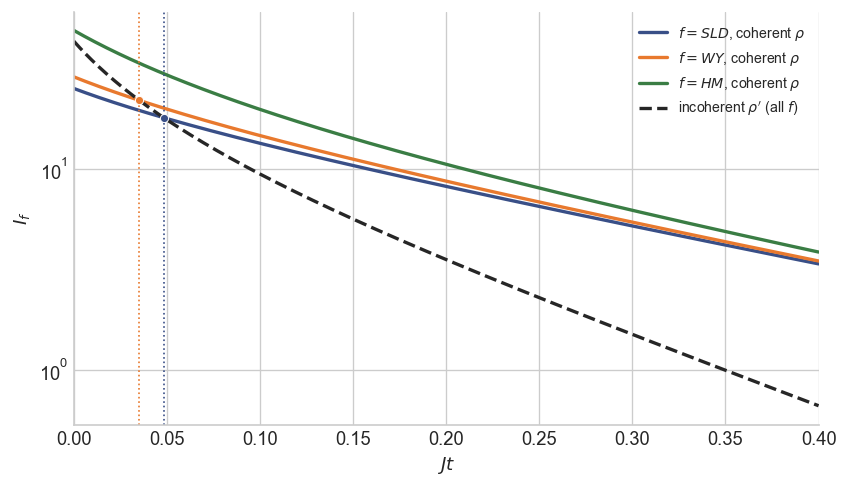

In [5]:
fig, ax = plt.subplots(figsize=(7.2, 4.2))
for name in qfi_functions:
    ax.semilogy(
        times,
        coherent_qfi[name],
        color=colors[name],
        lw=2,
        label=fr"$f={name}$, coherent $\rho$",
    )
ax.semilogy(
    times,
    incoherent_qfi["SLD"],
    color="0.15",
    lw=2,
    ls="--",
    label=r"incoherent $\rho'$ (all $f$)",
)
for name in ("SLD", "WY"):
    crossing_qfi = np.interp(
        crossing_times[name],
        times,
        coherent_qfi[name],
    )
    ax.axvline(
        crossing_times[name],
        color=colors[name],
        ls=":",
        lw=1,
    )
    ax.scatter(
        [crossing_times[name]],
        [crossing_qfi],
        s=24,
        color=colors[name],
        edgecolor="white",
        linewidth=0.6,
        zorder=5,
    )
ax.set(
    xlabel=r"$Jt$",
    ylabel=r"$I_f$",
    xlim=(times[0], times[-1]),
)
ax.legend(fontsize=8.5)
fig.tight_layout()
plt.show()


**Figure.** Metric-adjusted QFI along the same two Davies
trajectories. Dotted guides mark the SLD and WY crossings; the HM
ordering never reverses.

## Result

A Mpemba effect is a statement about a dynamics, a state pair, and a
chosen resource monotone. SLD and WY detect ordering reversals at
\(Jt_\times\simeq0.0483\) and \(0.0352\), respectively, while HM
detects none for the same physical trajectories.
